In [165]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency, chi2 
import scipy.stats as ss

In [166]:
orders = pd.read_csv('ab_orders.csv')
products = pd.read_csv('ab_products.csv')
users_data = pd.read_csv('ab_users_data.csv')

In [167]:
#ни в одной таблице нет пропущенных значений
print(orders.isna().sum().sum())
print(products.isna().sum().sum())
print(users_data.isna().sum().sum())

0
0
0


In [168]:
#пользователи группы 0
group0_list = set(users_data.query("group == 0").user_id)
len(group0_list)

515

In [169]:
#пользователи группы 1
group1_list = set(users_data.query("group == 1").user_id)
len(group1_list)

502

In [170]:
#проверим, есть ли пользователи, которые попали одновременны в обе группы
#таких пользователей нет
np.intersect1d(group0_list, group1_list)

array([], dtype=object)

<hr>

## Работа с отмененными заказами

В таблице users_data отображаются созданные заказы и отмененные.

Посмотрим на графике как соотносится количество отмененных заказов по отношению к количеству созданных в разных группах. 

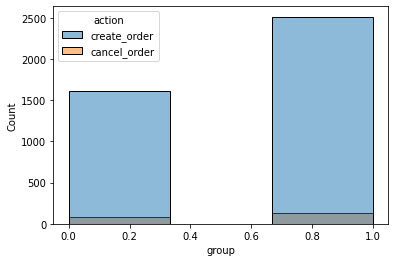

In [171]:
sns.histplot(data=users_data, x='group', hue='action', bins=3)

По графику складывается впечатление, что новая система рекомендаций никак не влияет на количество отмененных заказов (относительно количества созданных заказов).

Проверим эту гипотезу с помощью критерия Хи-квадрат

H0 - частота отмены заказов не зависит от группы

H1 - частота отмены заказов зависит от группы

In [172]:
stat, p, dof, expected = chi2_contingency(pd.crosstab(users_data.action, users_data.group))
stat, p

(0.018211165651942023, 0.8926523935841298)

p-value > 0.5 - нет оснований отклонить нулевую гипотезу - я делаю вывод что введение новой системы рекомендаций не влияет на количество отмен

<hr>

Я хочу убрать из таблицы users_data все заказы, которые были отменены (в том числе и созданные).

И добвлю в таблицу users_data данные о заказах

In [173]:
#убираем из таблицы все отмененные заказы
cancel_list = users_data.query("action == 'cancel_order'").order_id.to_list()
users_data = users_data.query("order_id not in @cancel_list")

<hr>

## Влияние новой рекомендательной системы на сам заказ (количество позиций, сумма заказа)

Я предполагаю, что новая система рекомендаций увеличит среднее количество товаров в одном чеке.

Для того, что бы это узнать, нам нужно добавить в таблицу колонку с количеством товаров в одном чеке.

In [174]:
#добавляем инфорацию о заказах
users_data = users_data.merge(orders[['order_id', 'product_ids']], on='order_id', how='left')

In [175]:
#в колонку quantity запишем количество товаров в каждом чеке
users_data['quantity'] = users_data.product_ids.apply(lambda x: len(x.replace('{', '').replace('}', '').split(',')))

In [176]:
users_data.head()

,user_id,order_id,action,time,date,group,product_ids,quantity
0,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,"{75, 22, 53, 84}",4
1,965,1256,create_order,2022-08-26 00:02:21.000000,2022-08-26,1,"{56, 76, 39}",3
2,964,1257,create_order,2022-08-26 00:02:27.000000,2022-08-26,0,"{76, 34, 41, 38}",4
3,967,1259,create_order,2022-08-26 00:03:37.000000,2022-08-26,1,"{20, 45, 67, 26}",4
4,968,1261,create_order,2022-08-26 00:05:35.000000,2022-08-26,0,"{30, 35, 69, 6}",4


In [177]:
gr0 = users_data.query("group == 0").quantity
gr1 = users_data.query("group == 1").quantity

/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


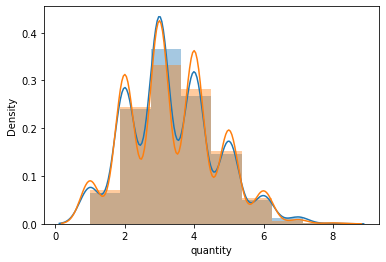

In [178]:
sns.distplot(gr0, bins=8)
sns.distplot(gr1, bins=8)

По графику сложно оценить различия, кажется что их нет.

Найдем среднее значение количества товаров в одном чеке для каждой группы.

In [179]:
print('Среднее значение в группе 0: ' + str(gr0.mean().round(2)))
print('Среднее значение в группе 1: ' + str(gr1.mean().round(2)))

Среднее значение в группе 0: 3.34
Среднее значение в группе 1: 3.35


Мы видим очень маленькие различия в средних значениях в двух группах.

Кажется, что эти различия могли получиться случайно. Проверим это с помощью t-теста.

H0 - Различий в средних значениях в двух группах нет, обе выборки могут принадлежать одной генеральной совокупности.

H1 - Есть различия в средних значениях в двух группах, выборки могут принадлежат разным генеральным совокупностям.

In [180]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=-0.19638057741712578, pvalue=0.84432251088501)

p-value > 0.05 - нет оснований отклонить нулевую гипотезу - следовательно различия между средними значаниями в двух группах не являются статистически значимыми

<hr>

Посмотрим, увеличит ли использование новой рекомендательной системы среднее значение суммы в чеке.

Для этого нам нужно создать таблицу, в поторой по каждому заказу мы сможем видеть развернутую информацию - список продуктов и цену каждого из продуктов в чеке

In [181]:
#создаю таблицу в которой будет развернутая информация по продуктам в каждом заказе
users_data.product_ids = users_data.product_ids.apply(lambda x: x.replace('{', '').replace('}', '').split(','))
order_by_prod = users_data.explode('product_ids').rename(columns={'product_ids': 'product_id'})
order_by_prod.product_id = order_by_prod.product_id.astype('int64')
order_by_prod = order_by_prod.merge(products, how='left', on='product_id')
order_by_prod.head()

,user_id,order_id,action,time,date,group,product_id,quantity,name,price
0,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,75,4,сок ананасовый,120.0
1,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,22,4,сок мультифрукт,120.0
2,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,53,4,мука,78.3
3,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,84,4,мандарины,90.4
4,965,1256,create_order,2022-08-26 00:02:21.000000,2022-08-26,1,56,3,сосиски,150.0


In [182]:
#Суммы чеков для каждой из групп
gr0 = order_by_prod.query("group == 0").groupby('order_id', as_index=False).agg({'price': 'sum'}).price
gr1 = order_by_prod.query("group == 1").groupby('order_id', as_index=False).agg({'price': 'sum'}).price

/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


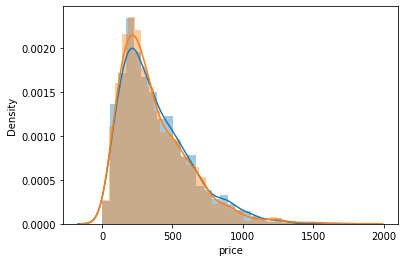

In [183]:
sns.distplot(gr0)
sns.distplot(gr1)

Снова кажется что различий в двух группах нет.

Найдем среднее значение суммы чеков для каждой группы.

In [184]:
print('Среднее значение в группе 0: ' + str(gr0.mean().round()))
print('Среднее значение в группе 1: ' + str(gr1.mean().round()))

Среднее значение в группе 0: 382.0
Среднее значение в группе 1: 369.0


Теперь мы видим что среднее значение в группе 1 меньше чем в группе 0.

Проверим, являются ли эти различия статистически значимыми с помощью t-теста.

H0 - Различий в средних значениях в двух группах нет, обе выборки могут принадлежать одной генеральной совокупности.

H1 - Есть различия в средних значениях в двух группах, выборки могут принадлежат разным генеральным совокупностям.

In [185]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=1.6334875192269402, pvalue=0.10244707728234669)

p-value > 0.05 - нет оснований отклонить нулевую гипотезу - следовательно различия между средними значаниями в двух группах не являются статистически значимыми

<hr>

## Влияние новой рекомендательной системы сам заказ в разбивке по пользователям (среднее количество позиций в чеке у пользователя, средний чек пользователя)

Теперь я хочу посмотреть, влияет ли новая рекомендательная система на среднее количество прозуктов в одном заказе и средний чек у пользователя.

Начнем со среднего количества продуктов в одном заказе у пользователей разных групп.

In [186]:
#среднее количество товаров в одном заказе у пользователей для разных групп
gr0 = users_data.query("group == 0").groupby('user_id', as_index=False).agg({'quantity': 'mean'}).quantity
gr1 = users_data.query("group == 1").groupby('user_id', as_index=False).agg({'quantity': 'mean'}).quantity

/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


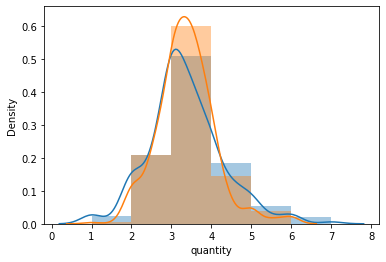

In [187]:
sns.distplot(gr0, bins=6)
sns.distplot(gr1, bins=5)

Снова кажется что различий в двух группах нет.

Найдем среднее значение среднего количества покупок для каждой группы.

In [188]:
print('Среднее значение в группе 0: ' + str(gr0.mean().round(3)))
print('Среднее значение в группе 1: ' + str(gr1.mean().round(3)))

Среднее значение в группе 0: 3.358
Среднее значение в группе 1: 3.364


Среднее значение в группе 1 немного больше чем в группе 0.

Проверим, являются ли эти различия статистически значимыми с помощью t-теста.

H0 - Различий в средних значениях в двух группах нет, обе выборки могут принадлежать одной генеральной совокупности.

H1 - Есть различия в средних значениях в двух группах, выборки могут принадлежат разным генеральным совокупностям.

In [189]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=-0.1133553419271026, pvalue=0.9097713480198675)

p-value > 0.05 - нет оснований отклонить нулевую гипотезу - следовательно различия между средними значаниями в двух группах не являются статистически значимыми

<hr>

Теперь посмотрим на средний чек у пользователей разных групп.

In [190]:
#средний чек у пользователей для разных групп
gr0 = order_by_prod \
    .query("group == 0") \
    .groupby(['user_id', 'order_id'], as_index=False) \
    .agg({'price': 'sum'}) \
    .groupby('user_id', as_index=False) \
    .agg({'price': 'mean'}) \
    .price
gr1 = order_by_prod \
    .query("group == 1") \
    .groupby(['user_id', 'order_id'], as_index=False) \
    .agg({'price': 'sum'}) \
    .groupby('user_id', as_index=False) \
    .agg({'price': 'mean'}) \
    .price

/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


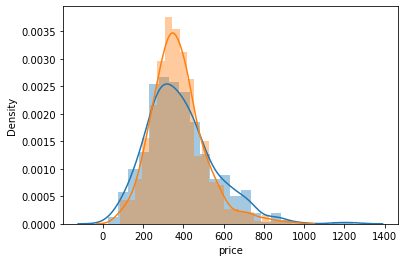

In [191]:
sns.distplot(gr0)
sns.distplot(gr1)

In [192]:
print('Среднее значение в группе 0: ' + str(gr0.mean().round()))
print('Среднее значение в группе 1: ' + str(gr1.mean().round()))

Среднее значение в группе 0: 386.0
Среднее значение в группе 1: 371.0


Снова среднее значение в группе 1 меньше чем в группе 0.

Проверим, являются ли эти различия статистически значимыми с помощью t-теста.

H0 - Различий в средних значениях в двух группах нет, обе выборки могут принадлежать одной генеральной совокупности.

H1 - Есть различия в средних значениях в двух группах, выборки могут принадлежат разным генеральным совокупностям.

In [193]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=1.5407052777251002, pvalue=0.12370144988523067)

p-value > 0.05 - нет оснований отклонить нулевую гипотезу - следовательно различия между средними значаниями в двух группах не являются статистически значимыми

<hr>

**Вопрос эксперту**

Относятся ли последние 4 теста к множественным сравнениям?

<hr>

## Влияние новой рекомендательной системы на количество заказов у пользователей

In [194]:
#количество заказов у пользователей разных групп
gr0 = users_data.query("group == 0").groupby('user_id', as_index=False).agg({'order_id': 'count'}).order_id
gr1 = users_data.query("group == 1").groupby('user_id', as_index=False).agg({'order_id': 'count'}).order_id

/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


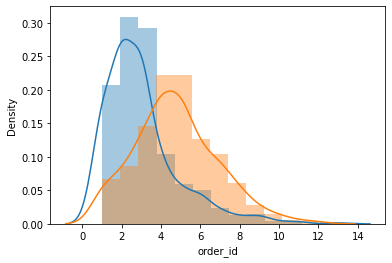

In [195]:
sns.distplot(gr0, bins=13)
sns.distplot(gr1, bins=12)

На графиках мы видим различия в распределении количества заказов.

In [196]:
print('Среднее значение в группе 0: ' + str(gr0.mean().round(2)))
print('Среднее значение в группе 1: ' + str(gr1.mean().round(2)))

Среднее значение в группе 0: 2.98
Среднее значение в группе 1: 4.75


Средние значения в группе 1 явно больше чем в группе 0.

Проверим, являются ли эти различия статистически значимыми с помощью t-теста.

H0 - Различий в средних значениях в двух группах нет, обе выборки могут принадлежать одной генеральной совокупности.

H1 - Есть различия в средних значениях в двух группах, выборки могут принадлежат разным генеральным совокупностям.

In [197]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=-13.993124788985595, pvalue=8.430777321728061e-41)

p-value < 0.05 - отклоняем нулевую гипотезу - различия между средними значаниями в двух группах являются статистически значимыми

<hr>

## Вывод:

Новая рекомендательная система увеличила среднее количество заказов на одного пользователя - пользователи стали делать заказы чаще. 

При этом сами заказы не изменились - не изменилось среднее количество позиций в одном заказе, и средний чек тоже не изменился